#Deep CNN Architectures

In [ ]:
pip install torch torchvision matplotlib

##Setup

In [ ]:
import math, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

torch.manual_seed(0) # Set random seed for reproducibility
device = "cuda" if torch.cuda.is_available() else "cpu" # Determine if GPU is available
print("PyTorch", torch.__version__, "| device:", device)

# Helper function to count the total number of trainable parameters in a model
def count_params(m):
    return sum(p.numel() for p in m.parameters())

# Helper function to trace the shapes and parameters of each layer in a sequential model
def trace(model, x, skip=()):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for tracing
        for i, layer in enumerate(model):
            x = layer(x)
            # Skip certain layers (e.g., activation functions, dropout) for parameter count display
            if not isinstance(layer, skip):
                name, shape = layer.__class__.__name__, str(tuple(x.shape)) #gets the name of layer's class
                print(f"{i:2d} {name:<18s} {shape:<20s} {count_params(layer):>12,}")
        print("total parameters:", f"{count_params(model):,}")

# ---- data: CIFAR-10, first 10000 train and 2000 test images, kept in memory ----
# Define transformations for the dataset: convert to tensor and normalize
tf = T.Compose([T.ToTensor(), T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
# Load CIFAR-10 training and testing datasets
train_set = torchvision.datasets.CIFAR10("data", train=True, download=True, transform=tf)
test_set = torchvision.datasets.CIFAR10("data", train=False, download=True, transform=tf)

# Function to load data subsets into Tensors
def load(ds):
    # Extract images and labels, then stack them into single tensors
    xs, ys = zip(*[ds[i] for i in range(len(ds))])
    return torch.stack(xs), torch.tensor(ys)

# Load a subset of the training and testing data
Xtr, Ytr = load(torch.utils.data.Subset(train_set, range(10000)))
Xte, Yte = load(torch.utils.data.Subset(test_set, range(2000)))
print("train", tuple(Xtr.shape), "| test", tuple(Xte.shape))

# ---- one training function for every network ----
# Function to calculate accuracy of the model on the test set
def accuracy(model):
    model.eval() # Set model to evaluation mode
    dev = next(model.parameters()).device # Get the device the model is on
    hits = 0
    with torch.no_grad(): # Disable gradient calculation
        # Process test data in batches of 500
        for i in range(0, len(Xte), 500):
            # Make predictions and move to CPU for comparison
            pred = model(Xte[i:i+500].to(dev)).argmax(1).cpu()
            hits += (pred == Yte[i:i+500]).sum().item() # Count correct predictions
    return hits / len(Xte) # Return overall accuracy

# Dictionary to store results of each model
results = {}

# Training function for a given model
def fit(name, model, epochs=4):
    model.to(device) # Move model to the selected device (CPU/GPU)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3) # Adam optimizer
    start = time.time() # Start time for training duration calculation
    for ep in range(epochs):
        model.train() # Set model to training mode
        order = torch.randperm(len(Xtr)) # Random permutation of training data indices
        for i in range(0, len(order), 64): # Iterate through mini-batches of size 64
            idx = order[i:i+64] # Get indices for the current batch
            opt.zero_grad() # Zero the gradients
            # Calculate loss: forward pass, compute cross-entropy loss
            loss = F.cross_entropy(model(Xtr[idx].to(device)), Ytr[idx].to(device))
            loss.backward() # Backward pass: compute gradients
            opt.step() # Update model parameters
        acc = accuracy(model) # Calculate accuracy after each epoch
        print(f"{name:<15s} epoch {ep+1}: test accuracy {acc:.3f}")
    # Store model performance metrics in the results dictionary
    results[name] = {"params": count_params(model), "seconds": round(time.time() - start), "acc": acc}

PyTorch 2.11.0+cpu | device: cpu
train (10000, 3, 32, 32) | test (2000, 3, 32, 32)


##Experiment 1 — LeNet-5

In [ ]:
def make_lenet(num_classes=10):
  # LeNet-5 architecture definition
  return nn.Sequential(
    # C1 Convolutional layer: 3 input channels, 6 output channels, 5x5 kernel
    nn.Conv2d(3, 6, 5), nn.Tanh(), # Input 32x32 -> Output 28x28
    nn.AvgPool2d(2), # S2 Average Pooling: 28x28 -> 14x14
    # C3 Convolutional layer: 6 input channels, 16 output channels, 5x5 kernel
    nn.Conv2d(6, 16, 5), nn.Tanh(), # Input 14x14 -> Output 10x10
    nn.AvgPool2d(2), # S4 Average Pooling: 10x10 -> 5x5
    # C5 Convolutional layer: 16 input channels, 120 output channels, 5x5 kernel
    nn.Conv2d(16, 120, 5), nn.Tanh(), # Input 5x5 -> Output 1x1
    nn.Flatten(), # Flatten the 1x1x120 tensor to a 120-element vector
    nn.Linear(120, 84), nn.Tanh(), # F6 Fully connected layer: 120 -> 84 neurons
    nn.Linear(84, num_classes)) # Output layer: 84 -> num_classes

lenet = make_lenet() # Instantiate LeNet-5 model
# Trace the model to inspect layer shapes and parameter counts, skipping Tanh layers
trace(lenet, torch.zeros(1, 3, 32, 32), skip=(nn.Tanh,))

 0 Conv2d             (1, 6, 28, 28)                456
 2 AvgPool2d          (1, 6, 14, 14)                  0
 3 Conv2d             (1, 16, 10, 10)             2,416
 5 AvgPool2d          (1, 16, 5, 5)                   0
 6 Conv2d             (1, 120, 1, 1)             48,120
 8 Flatten            (1, 120)                        0
 9 Linear             (1, 84)                    10,164
11 Linear             (1, 10)                       850
total parameters: 62,006


In [ ]:
print("C1 by hand:", (5*5*3 + 1) * 6) # Manual calculation for parameters of C1 layer
print("C3 by hand:", (5*5*6 + 1) * 16) # Manual calculation for parameters of C3 layer
# Calculate parameters for a hypothetical dense layer equivalent to C1
# This shows how many more parameters a fully connected layer would have compared to a convolutional layer
print("dense equivalent of C1:", f"{(32*32*3 + 1) * 6*28*28:,}")

C1 by hand: 456
C3 by hand: 2416
dense equivalent of C1: 14,455,392


In [ ]:
fit("LeNet-5", lenet) # Train the LeNet-5 model

LeNet-5         epoch 1: test accuracy 0.351
LeNet-5         epoch 2: test accuracy 0.378
LeNet-5         epoch 3: test accuracy 0.403
LeNet-5         epoch 4: test accuracy 0.421


##Experiment 2 — AlexNet.
works on 227×227 colour images, and brought several practices together: ReLU
activations instead of tanh (the gradient is exactly 1 for positive inputs, so deep networks train faster), dropout in the
fully connected layers (random units are switched off during training to reduce overfitting), data augmentation, and
GPU training. The first convolution uses a large 11×11 filter with stride 4 to shrink the image quickly.

In [ ]:
def make_alexnet(num_classes=1000):
  # AlexNet architecture definition
  return nn.Sequential(
    # First convolutional layer: large kernel, stride 4, ReLU activation
    nn.Conv2d(3, 96, 11, stride=4), nn.ReLU(), # Input 227x227 -> 55x55
    nn.MaxPool2d(3, 2), # Max Pooling: 55x55 -> 27x27
    # Second convolutional layer: 5x5 kernel, padding 2, ReLU
    nn.Conv2d(96, 256, 5, padding=2), nn.ReLU(), # Input 27x27 -> 27x27
    nn.MaxPool2d(3, 2), # Max Pooling: 27x27 -> 13x13
    # Third convolutional layer: 3x3 kernel, padding 1, ReLU
    nn.Conv2d(256, 384, 3, padding=1), nn.ReLU(),
    # Fourth convolutional layer: 3x3 kernel, padding 1, ReLU
    nn.Conv2d(384, 384, 3, padding=1), nn.ReLU(),
    # Fifth convolutional layer: 3x3 kernel, padding 1, ReLU
    nn.Conv2d(384, 256, 3, padding=1), nn.ReLU(),
    nn.MaxPool2d(3, 2), # Max Pooling: 13x13 -> 6x6
    nn.Flatten(), # Flatten the 256*6*6 tensor to a vector (9216 elements)
    # Fully connected layers with Dropout and ReLU activations
    nn.Dropout(0.5), nn.Linear(9216, 4096), nn.ReLU(),
    nn.Dropout(0.5), nn.Linear(4096, 4096), nn.ReLU(),
    nn.Linear(4096, num_classes)) # Output layer

alexnet = make_alexnet() # Instantiate AlexNet model
# Trace the model to inspect layer shapes and parameter counts, skipping ReLU and Dropout layers
trace(alexnet, torch.zeros(1, 3, 227, 227), skip=(nn.ReLU, nn.Dropout))

 0 Conv2d             (1, 96, 55, 55)            34,944
 2 MaxPool2d          (1, 96, 27, 27)                 0
 3 Conv2d             (1, 256, 27, 27)          614,656
 5 MaxPool2d          (1, 256, 13, 13)                0
 6 Conv2d             (1, 384, 13, 13)          885,120
 8 Conv2d             (1, 384, 13, 13)        1,327,488
10 Conv2d             (1, 256, 13, 13)          884,992
12 MaxPool2d          (1, 256, 6, 6)                  0
13 Flatten            (1, 9216)                       0
15 Linear             (1, 4096)              37,752,832
18 Linear             (1, 4096)              16,781,312
20 Linear             (1, 1000)               4,097,000
total parameters: 62,378,344


In [ ]:
# Calculate total parameters in convolutional layers
conv_p = sum(count_params(l) for l in alexnet if isinstance(l, nn.Conv2d))
# Calculate total parameters in fully connected layers
fc_p = sum(count_params(l) for l in alexnet if isinstance(l, nn.Linear))
# Print the parameter counts and the share of FC layer parameters
print(f"conv {conv_p:,} fc {fc_p:,} fc share {fc_p / (conv_p + fc_p):.1%}")
# Manual calculation for the first convolutional layer of AlexNet
print("Conv1 by hand:", (11*11*3 + 1) * 96, "| size", (227 - 11) // 4 + 1)

conv 3,747,200 fc 58,631,144 fc share 94.0%
Conv1 by hand: 34944 | size 55


In [ ]:
def make_alexnet_lite(num_classes=10):
  # AlexNet-lite architecture for smaller input images (e.g., CIFAR-10 32x32)
  return nn.Sequential(
    # First block: Conv, ReLU, MaxPool
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # Input 32x32 -> 16x16
    # Second block: Conv, ReLU, MaxPool
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # Input 16x16 -> 8x8
    # Subsequent convolutional layers without pooling for finer feature extraction
    nn.Conv2d(64, 96, 3, padding=1), nn.ReLU(),
    nn.Conv2d(96, 96, 3, padding=1), nn.ReLU(),
    # Final convolutional block with pooling
    nn.Conv2d(96, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # Input 8x8 -> 4x4
    nn.Flatten(), # Flatten the 64*4*4 tensor to a vector (1024 elements)
    # Fully connected layers with Dropout and ReLU activations
    nn.Dropout(0.5), nn.Linear(1024, 256), nn.ReLU(),
    nn.Dropout(0.5), nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, num_classes)) # Output layer

alexnet_lite = make_alexnet_lite() # Instantiate AlexNet-lite model
print("parameters:", f"{count_params(alexnet_lite):,}") # Print total parameters
fit("AlexNet-lite", alexnet_lite) # Train AlexNet-lite model

parameters: 543,946
AlexNet-lite    epoch 1: test accuracy 0.337
AlexNet-lite    epoch 2: test accuracy 0.374
AlexNet-lite    epoch 3: test accuracy 0.439
AlexNet-lite    epoch 4: test accuracy 0.484


##Experiment 3 — VGG-16
It
uses only 3×3 convolutions with stride 1 and padding 1, and a 2×2 max pooling layer at the end of each block.
Resolution changes only at pooling, and the channel count grows block by block: 64, 128, 256, 512, 512. VGG-16 has
13 convolution layers and 3 fully connected layers. Two stacked 3×3 convolutions see a 5×5 region and three see 7×7,
so a stack of small filters covers the same area as one large filter with fewer weights and more nonlinearities in
between. The price is size: about 138 million parameters.

In [ ]:
def vgg_block(c_in, c_out, n_convs, bn=False):
    # Helper function to create a VGG-style block of convolutional layers
    layers = []
    for i in range(n_convs):
        # Add convolutional layer, handling input channels for the first conv in the block
        layers.append(nn.Conv2d(c_in if i == 0 else c_out, c_out, 3, padding=1))
        if bn:
            layers.append(nn.BatchNorm2d(c_out)) # Add Batch Normalization if requested
        layers.append(nn.ReLU()) # Add ReLU activation
    layers.append(nn.MaxPool2d(2, 2)) # Add Max Pooling at the end of the block
    return nn.Sequential(*layers)

def make_vgg16(num_classes=1000):
    # VGG-16 architecture definition
    return nn.Sequential(
        # Stacking VGG blocks with increasing channel counts
        vgg_block(3, 64, 2), vgg_block(64, 128, 2), vgg_block(128, 256, 3),
        vgg_block(256, 512, 3), vgg_block(512, 512, 3),
        nn.Flatten(),  # Flatten the output for fully connected layers (512*7*7 = 25088)
        # Fully connected layers with ReLU and Dropout
        nn.Linear(25088, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, num_classes)) # Output layer
vgg16 = make_vgg16() # Instantiate VGG-16 model
# Trace the model to inspect layer shapes and parameter counts, skipping ReLU and Dropout layers
trace(vgg16, torch.zeros(1, 3, 224, 224), skip=(nn.ReLU, nn.Dropout))

 0 Sequential         (1, 64, 112, 112)          38,720
 1 Sequential         (1, 128, 56, 56)          221,440
 2 Sequential         (1, 256, 28, 28)        1,475,328
 3 Sequential         (1, 512, 14, 14)        5,899,776
 4 Sequential         (1, 512, 7, 7)          7,079,424
 5 Flatten            (1, 25088)                      0
 6 Linear             (1, 4096)             102,764,544
 9 Linear             (1, 4096)              16,781,312
12 Linear             (1, 1000)               4,097,000
total parameters: 138,357,544


Compare one 5×5 convolution with two 3×3 convolutions (64 channels in and out), and compute the receptive field of
three stacked 3×3 layers.

In [ ]:
C = 64 # Number of channels
# Calculate parameters for a single 5x5 convolutional layer
one_5x5 = count_params(nn.Conv2d(C, C, 5, padding=2))
# Calculate parameters for two stacked 3x3 convolutional layers with ReLU in between
two_3x3 = count_params(nn.Sequential(nn.Conv2d(C, C, 3, padding=1), nn.ReLU(),
nn.Conv2d(C, C, 3, padding=1)))
print(f"one 5x5 : {one_5x5:,}") # Print parameters for one 5x5 conv
print(f"two 3x3 : {two_3x3:,}") # Print parameters for two 3x3 convs
# Calculate and print parameter saving percentage when using two 3x3 instead of one 5x5
print(f"saving : {100 * (one_5x5 - two_3x3) / one_5x5:.1f}%")

r, j = 1, 1 # Initialize receptive field (r) and jump (j)
for n in range(1, 4): # Loop to calculate receptive field for 1, 2, and 3 stacked 3x3 convs
  r, j = r + (3 - 1) * j, j * 1 # Update receptive field and jump (stride is 1)
  print(f"{n} conv(s): receptive field {r}x{r}")

one 5x5 : 102,464
two 3x3 : 73,856
saving : 27.9%
1 conv(s): receptive field 3x3
2 conv(s): receptive field 5x5
3 conv(s): receptive field 7x7


Now the narrow, batch-normalised version with the same 13-convolution layout. After five poolings a 32×32 image is
1×1, so the flattened size is just the last channel count.

In [ ]:
def make_vgg_lite(num_classes=10):
  # VGG-lite architecture with Batch Normalization, adapted for smaller inputs
  return nn.Sequential(
    # VGG blocks with increasing channel counts and Batch Normalization
    vgg_block(3, 16, 2, bn=True), vgg_block(16, 32, 2, bn=True), vgg_block(32, 64, 3, bn=True),
    vgg_block(64, 128, 3, bn=True), vgg_block(128, 128, 3, bn=True),
    nn.Flatten(), # Flatten the output for fully connected layers (128*1*1 = 128 after 5 poolings for 32x32 input)
    # Fully connected layers with ReLU and Dropout
    nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, num_classes)) # Output layer

vgg_lite = make_vgg_lite() # Instantiate VGG-lite model
print("parameters:", f"{count_params(vgg_lite):,}") # Print total parameters
fit("VGG-16-lite", vgg_lite) # Train VGG-16-lite model

parameters: 1,024,282
VGG-16-lite     epoch 1: test accuracy 0.296
VGG-16-lite     epoch 2: test accuracy 0.345
VGG-16-lite     epoch 3: test accuracy 0.382
VGG-16-lite     epoch 4: test accuracy 0.444


##Experiment 4 — PlacesNet
PlacesNet is the name commonly given to CNNs trained on the Places dataset: millions of photographs
labelled by scene (kitchen, airport, forest, classroom) instead of by object. The widely used version has 365 scene
categories. The network body is an ordinary CNN. The first Places-CNN used an AlexNet-style backbone, and later
versions moved to VGG and ResNet backbones. What changes is the target. For a label like "airport" the evidence is
the whole layout and context, not one object, so two things matter: how many classes the last layer separates, and
how much of the image a late unit can see.

In [ ]:
placesnet = make_alexnet(num_classes=365) # Instantiate AlexNet for 365 classes (PlacesNet)
print("PlacesNet parameters:", f"{count_params(placesnet):,}") # Print parameters for PlacesNet
print("AlexNet parameters :", f"{count_params(alexnet):,}") # Print parameters for original AlexNet
# Calculate and print the difference in parameters due to the different number of output classes
print("difference :", f"{count_params(alexnet) - count_params(placesnet):,}")
print(placesnet[20]) # Print the last layer (output layer), which is the only one that differs

PlacesNet parameters: 59,776,749
AlexNet parameters : 62,378,344
difference : 2,601,595
Linear(in_features=4096, out_features=365, bias=True)


A softmax and loss calculation by hand, and the receptive field of one unit at each stage of the AlexNet body (kernel
size and stride for each layer).

In [ ]:
logits = torch.tensor([2.0, 1.0, 0.0]) # Example raw scores (logits)
q = F.softmax(logits, dim=0) # Apply softmax to convert logits to probabilities
print("probabilities:", [round(v, 3) for v in q.tolist()]) # Print rounded probabilities
# Calculate cross-entropy loss assuming the first class is the true class
print("loss if class 1 is true:", round(-torch.log(q[0]).item(), 3))
# Calculate the loss of a random guess in a 365-way classification problem
print("loss of a 365-way guess at random = ln(365) =", round(math.log(365), 2))
r, j = 1, 1 # Initialize receptive field (r) and jump (j)
# Define stages of a convolutional network with kernel size (k) and stride (s)
stages = [("conv1", 11, 4), ("pool1", 3, 2), ("conv2", 5, 1), ("pool2", 3, 2),
("conv3", 3, 1), ("conv4", 3, 1), ("conv5", 3, 1), ("pool5", 3, 2)]
for name, k, s in stages:
  # Update receptive field calculation for each stage
  r, j = r + (k - 1) * j, j * s
  # Print the receptive field size and its percentage of the image width
  print(f"{name}: receptive field {r:3d} px ({r / 227:.0%} of image width)")

probabilities: [0.665, 0.245, 0.09]
loss if class 1 is true: 0.408
loss of a 365-way guess at random = ln(365) = 5.9
conv1: receptive field  11 px (5% of image width)
pool1: receptive field  19 px (8% of image width)
conv2: receptive field  51 px (22% of image width)
pool2: receptive field  67 px (30% of image width)
conv3: receptive field  99 px (44% of image width)
conv4: receptive field 131 px (58% of image width)
conv5: receptive field 163 px (72% of image width)
pool5: receptive field 195 px (86% of image width)


In [ ]:
places_lite = make_alexnet_lite(num_classes=365) # Instantiate AlexNet-lite for 365 classes
print("parameters:", f"{count_params(places_lite):,}") # Print total parameters
fit("PlacesNet-lite", places_lite) # Train PlacesNet-lite model

parameters: 635,181
PlacesNet-lite  epoch 1: test accuracy 0.192
PlacesNet-lite  epoch 2: test accuracy 0.291
PlacesNet-lite  epoch 3: test accuracy 0.383
PlacesNet-lite  epoch 4: test accuracy 0.422


##Experiment 5 — ResNet-18
layout. A 7×7 stride-2 convolution and a 3×3 stride-2 max pool (224 down to 56), then four stages of two
basic blocks each with 64, 128, 256 and 512 channels. The first block of stages 2 to 4 halves the resolution with stride
2 and uses a 1×1 convolution on the shortcut so both branches have the same shape. Batch normalisation follows
every convolution. The network ends with global average pooling and one linear layer, instead of the large fully
connected head of AlexNet and VGG.

In [ ]:
class BasicBlock(nn.Module):
  # Basic Block for ResNet architecture
  def __init__(self, c_in, c_out, stride=1):
    super().__init__()
    # First convolutional layer
    self.conv1 = nn.Conv2d(c_in, c_out, 3, stride, 1, bias=False)
    self.bn1 = nn.BatchNorm2d(c_out)
    # Second convolutional layer
    self.conv2 = nn.Conv2d(c_out, c_out, 3, 1, 1, bias=False)
    self.bn2 = nn.BatchNorm2d(c_out)
    self.shortcut = nn.Sequential() # Initialize shortcut connection as identity
    # If input and output shapes don't match, apply 1x1 convolution for shortcut
    if stride != 1 or c_in != c_out:
      self.shortcut = nn.Sequential(nn.Conv2d(c_in, c_out, 1, stride, bias=False),nn.BatchNorm2d(c_out))

  def forward(self, x):
    # Forward pass through the block: Conv -> BN -> ReLU -> Conv -> BN -> Add shortcut -> ReLU
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv2(out))
    return F.relu(out + self.shortcut(x))


blk = BasicBlock(64, 64).eval() # Instantiate a BasicBlock with 64 input/output channels, set to evaluation mode
for p in blk.parameters():
  nn.init.zeros_(p) # Initialize all parameters to zero (forces F(x) = 0 for testing)
x = torch.randn(1, 64, 8, 8) # Create a dummy input tensor
# Test if F(x) = 0 implies y equals relu(x) (identity mapping for residual connection)
print("F(x) = 0 -> y equals relu(x):", torch.allclose(blk(x), F.relu(x)))

F(x) = 0 -> y equals relu(x): True


In [ ]:
def res_stages(base):
    # Helper function to create ResNet stages, each consisting of BasicBlocks
    layers, c_in = [], base # Initialize layers list and input channels
    # Define channel multipliers and strides for each stage
    for mult, stride in [(1, 1), (2, 2), (4, 2), (8, 2)]:
        c_out = base * mult # Calculate output channels for the stage
        # Add two BasicBlocks to the stage (first one might have stride > 1)
        layers += [BasicBlock(c_in, c_out, stride), BasicBlock(c_out, c_out)]
        c_in = c_out # Update input channels for the next stage
    return layers

def make_resnet18(num_classes=1000): # for 224x224 images
    # ResNet-18 architecture definition for 224x224 input images
    return nn.Sequential(
        # Initial convolutional layer
        nn.Conv2d(3, 64, 7, 2, 3, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
        nn.MaxPool2d(3, 2, 1), # Max pooling
        *res_stages(64), # Unpack the BasicBlocks from res_stages
        nn.AdaptiveAvgPool2d(1), # Global average pooling to reduce spatial dimensions to 1x1
        nn.Flatten(), # Flatten for the final fully connected layer
        nn.Linear(512, num_classes)) # Output linear layer

trace(make_resnet18(), torch.zeros(1, 3, 224, 224), skip=(nn.ReLU,)) # Trace ResNet-18 model, skipping ReLU

 0 Conv2d             (1, 64, 112, 112)           9,408
 1 BatchNorm2d        (1, 64, 112, 112)             128
 3 MaxPool2d          (1, 64, 56, 56)                 0
 4 BasicBlock         (1, 64, 56, 56)            73,984
 5 BasicBlock         (1, 64, 56, 56)            73,984
 6 BasicBlock         (1, 128, 28, 28)          230,144
 7 BasicBlock         (1, 128, 28, 28)          295,424
 8 BasicBlock         (1, 256, 14, 14)          919,040
 9 BasicBlock         (1, 256, 14, 14)        1,180,672
10 BasicBlock         (1, 512, 7, 7)          3,673,088
11 BasicBlock         (1, 512, 7, 7)          4,720,640
12 AdaptiveAvgPool2d  (1, 512, 1, 1)                  0
13 Flatten            (1, 512)                        0
14 Linear             (1, 1000)                 513,000
total parameters: 11,689,512


In [ ]:
class DeepStack(nn.Module):
    # A custom module to demonstrate gradient flow in deep plain vs. residual networks
    def __init__(self, residual, depth=20, c=16):
        super().__init__()
        self.residual = residual # Boolean to enable/disable residual connections
        # Create a list of convolutional layers
        self.convs = nn.ModuleList([nn.Conv2d(c, c, 3, padding=1) for _ in range(depth)])

    def forward(self, x):
        for conv in self.convs:
            # Apply convolution and ReLU. If residual, add input x before ReLU.
            x = F.relu(conv(x)) + x if self.residual else F.relu(conv(x))
        return x

x = torch.randn(4, 16, 16, 16) # Create a dummy input tensor
for residual in (False, True):
    torch.manual_seed(0) # Set seed for reproducibility
    net = DeepStack(residual) # Instantiate DeepStack network (plain or residual)
    # Compute a dummy loss and backward pass to get gradients
    net(x).pow(2).mean().backward()
    # Get the L2 norm of the gradient of the first convolutional layer's weights
    g = net.convs[0].weight.grad.norm().item()
    # Print the gradient norm, demonstrating better gradient flow with residual connections
    print("residual" if residual else "plain ", f"gradient norm at layer 1: {g:.2e}")

plain  gradient norm at layer 1: 3.01e-11
residual gradient norm at layer 1: 6.04e+02


In [ ]:
def make_resnet_lite(num_classes=10):
  # ResNet-18-lite architecture for smaller input images (e.g., CIFAR-10 32x32)
  return nn.Sequential(
    # Initial convolutional layer with Batch Normalization
    nn.Conv2d(3, 16, 3, 1, 1, bias=False), nn.BatchNorm2d(16), nn.ReLU(),
    *res_stages(16), # Unpack ResNet stages starting with 16 channels
    nn.AdaptiveAvgPool2d(1), # Global average pooling
    nn.Flatten(), # Flatten for the final fully connected layer
    nn.Linear(128, num_classes)) # Output linear layer (128 is the output channels from last res_stage block)

resnet_lite = make_resnet_lite() # Instantiate ResNet-18-lite model
print("parameters:", f"{count_params(resnet_lite):,}") # Print total parameters
fit("ResNet-18-lite", resnet_lite) # Train ResNet-18-lite model

parameters: 701,466
ResNet-18-lite  epoch 1: test accuracy 0.404
ResNet-18-lite  epoch 2: test accuracy 0.464
ResNet-18-lite  epoch 3: test accuracy 0.579
ResNet-18-lite  epoch 4: test accuracy 0.514


## Conclusion

network            params  time (s)  test acc
LeNet-5            62,006        14     0.421
AlexNet-lite      543,946       138     0.484
VGG-16-lite     1,024,282       185     0.444
PlacesNet-lite    635,181       139     0.422
ResNet-18-lite    701,466       315     0.514


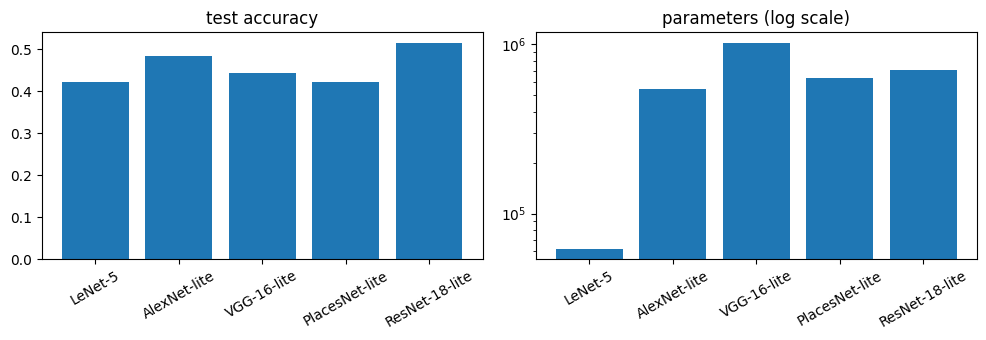

In [ ]:
names = list(results) # Get the names of all trained models
# Print a header for the results table
print(f"{'network':<15}{'params':>10}{'time (s)':>10}{'test acc':>10}")
# Iterate through each model's results and print them in a formatted table
for n in names:
    r = results[n]
    print(f"{n:<15}{r['params']:>10,}{r['seconds']:>10}{r['acc']:>10.3f}")

# Create a figure with two subplots for visualization
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
# Plot test accuracy for each network
ax[0].bar(names, [results[n]["acc"] for n in names])
ax[0].set_title("test accuracy")
# Plot parameters (on a log scale) for each network
ax[1].bar(names, [results[n]["params"] for n in names])
ax[1].set_yscale("log") # Set y-axis to log scale for parameters
ax[1].set_title("parameters (log scale)")
# Rotate x-axis labels for better readability in both subplots
for a in ax:
    a.tick_params(axis="x", rotation=30)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("comparison.png") # Save the comparison plot
plt.show() # Display the plot

### Summary of Model Comparison

From the results, we can observe the following:

*   **LeNet-5:** This model has the fewest parameters (62,006) and a test accuracy of 0.421. It's the simplest and fastest to train, but also the least accurate among the tested models.
*   **AlexNet-lite:** With 543,946 parameters, it's more complex than LeNet-5 and achieves a higher test accuracy of 0.484. The training time is also significantly longer.
*   **VGG-16-lite:** This model is the most complex in terms of parameters (1,024,282) but did not achieve the highest accuracy (0.444). Its training time was the longest.
*   **PlacesNet-lite:** Similar in parameter count to AlexNet-lite (635,181), it achieved a test accuracy of 0.422, which is comparable to LeNet-5 despite its higher complexity.
*   **ResNet-18-lite:** This model has 701,466 parameters and achieved the highest test accuracy of 0.514, demonstrating the effectiveness of residual connections in improving performance, even with a moderate increase in parameters compared to AlexNet-lite and PlacesNet-lite.

In conclusion, **ResNet-18-lite** offers the best trade-off between accuracy and complexity for this specific dataset and training setup, achieving the highest test accuracy while not being the most parameter-heavy model.